In [23]:
import pandas as pd
import numpy as np



In [15]:
df= pd.read_csv("job_postings.csv")

In [17]:
df.shape

(12217, 15)

In [19]:
clean_df=df.copy()

In [21]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12217 entries, 0 to 12216
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_link             12217 non-null  object
 1   last_processed_time  12217 non-null  object
 2   last_status          12217 non-null  object
 3   got_summary          12217 non-null  object
 4   got_ner              12217 non-null  object
 5   is_being_worked      12217 non-null  object
 6   job_title            12217 non-null  object
 7   company              12217 non-null  object
 8   job_location         12216 non-null  object
 9   first_seen           12217 non-null  object
 10  search_city          12217 non-null  object
 11  search_country       12217 non-null  object
 12  search_position      12217 non-null  object
 13  job_level            12217 non-null  object
 14  job_type             12217 non-null  object
dtypes: object(15)
memory usage: 1.4+ MB


In [25]:
clean_df.describe(include= "all")

,job_link,last_processed_time,last_status,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type
count,12217,12217,12217,12217,12217,12217,12217,12217,12216,12217,12217,12217,12217,12217,12217
unique,12217,5763,1,1,1,1,6484,3947,2049,6,801,4,711,2,3
top,https://www.linkedin.com/jobs/view/senior-mach...,2024-01-19 09:45:09.215838+00,Finished NER,t,t,f,Senior Data Engineer,Jobs for Humanity,"New York, NY",2024-01-13,Greater London,United States,Data Entry Clerk,Mid senior,Onsite
freq,1,6455,12217,12217,12217,12217,285,732,280,4946,189,10291,1088,10919,12188


In [29]:
clean_df.nunique()

job_link               12217
last_processed_time     5763
last_status                1
got_summary                1
got_ner                    1
is_being_worked            1
job_title               6484
company                 3947
job_location            2049
first_seen                 6
search_city              801
search_country             4
search_position          711
job_level                  2
job_type                   3
dtype: int64

In [31]:
clean_df.isnull().sum()

job_link               0
last_processed_time    0
last_status            0
got_summary            0
got_ner                0
is_being_worked        0
job_title              0
company                0
job_location           1
first_seen             0
search_city            0
search_country         0
search_position        0
job_level              0
job_type               0
dtype: int64

In [33]:
clean_df.duplicated().sum()

0

In [35]:
clean_df["job_link"].duplicated().sum()

0

In [37]:
clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [39]:
clean_df["company"] = clean_df["company"].str.strip()

In [41]:
text_columns = clean_df.select_dtypes(include="object").columns

In [43]:
for col in text_columns:
    clean_df[col] = clean_df[col].str.strip()

In [45]:
clean_df[clean_df["job_location"].isna()]

,job_link,last_processed_time,last_status,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type
9885,https://www.linkedin.com/jobs/view/sr-data-eng...,2024-01-20 04:25:45.213731+00,Finished NER,t,t,f,"Sr. Data Engineer, Abuse Test & Engineering",Tesla,NaN,2024-01-17,Alameda,United States,Test Engineer Mechanical Equipment,Mid senior,Onsite


In [47]:
clean_df["job_location"] = clean_df["job_location"].fillna("Unknown")

In [49]:
clean_df["last_processed_time"] = pd.to_datetime(
    clean_df["last_processed_time"],
    
)

In [51]:
clean_df["first_seen"] = pd.to_datetime(
    clean_df["first_seen"],
    
)

In [53]:
clean_df["first_seen"].dt.year

0        2024
1        2024
2        2024
3        2024
4        2024
         ... 
12212    2024
12213    2024
12214    2024
12215    2024
12216    2024
Name: first_seen, Length: 12217, dtype: int32

In [55]:
clean_df["first_seen"].dt.month

0        1
1        1
2        1
3        1
4        1
        ..
12212    1
12213    1
12214    1
12215    1
12216    1
Name: first_seen, Length: 12217, dtype: int32

In [57]:
clean_df["job_type"].value_counts()

job_type
Onsite    12188
Remote       18
Hybrid       11
Name: count, dtype: int64

In [59]:
clean_df["job_level"].value_counts()

job_level
Mid senior    10919
Associate      1298
Name: count, dtype: int64

In [61]:
clean_df["search_country"].value_counts()

search_country
United States     10291
United Kingdom      995
Canada              630
Australia           301
Name: count, dtype: int64

In [63]:
clean_df["search_position"].value_counts()

search_position
Data Entry Clerk                  1088
Data Base Administrator           1016
Agricultural-Research Engineer     943
Data Communications Analyst        883
Architect                          462
                                  ... 
Supervisor Coffee                    1
Mathematical Technician              1
Loader                               1
Form Builder                         1
Tourist-Information Assistant        1
Name: count, Length: 711, dtype: int64


  ### I inspected the columns and determined these variables were constant and not useful for analysis.


In [66]:
analysis_df = clean_df.drop(
    columns=[
        "last_status",
        "got_summary",
        "got_ner",
        "is_being_worked"
    ]
)

### What are the most common job titles?


In [75]:
analysis_df["job_title"].value_counts().head(10)

job_title
Senior Data Engineer                         285
Senior Data Analyst                          163
Data Engineer                                149
Senior MLOps Engineer                        138
Data Analyst                                 137
Data Scientist                               128
Lead Data Engineer                           123
Senior Data Scientist                        119
Data Architect                               111
Staff Machine Learning Engineer, Series A    101
Name: count, dtype: int64

<Axes: title={'center': 'Top 10 Job Titles'}, ylabel='job_title'>

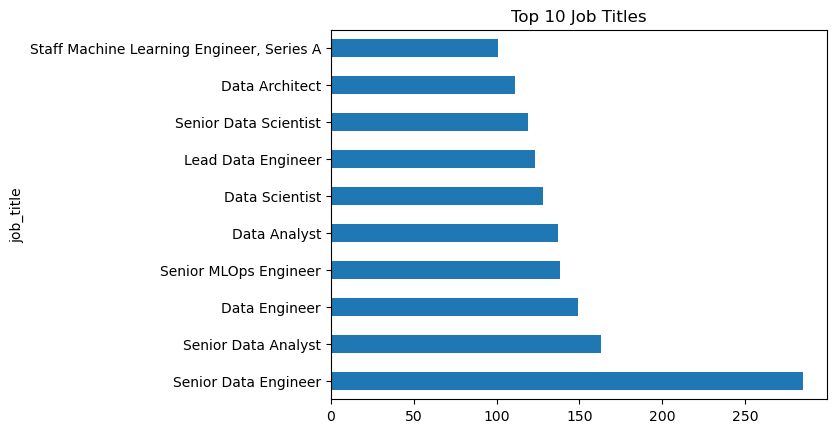

In [79]:
analysis_df["job_title"].value_counts().head(10).plot(
    kind="barh",
    title="Top 10 Job Titles"
)

### Which companies post the most jobs?

In [85]:
analysis_df["company"].value_counts().head(10)

company
Jobs for Humanity            732
Recruiting from Scratch      390
Dice                         193
Agoda                        172
ClearanceJobs                166
ClickJobs.io                 152
Capital One                   92
Energy Jobline                73
Amazon Web Services (AWS)     72
Deloitte                      67
Name: count, dtype: int64

### Which cities have the most jobs?

In [88]:
analysis_df["search_city"].value_counts().head(15)

search_city
Greater London    189
Austin            172
Garland           137
Santa Clara       137
Baytown           117
Chicago           116
Eastchester       113
Summit            109
Bound Brook       106
Montpelier        105
Novato            103
Alexandria         99
Manassas           98
Norristown         91
North Carolina     89
Name: count, dtype: int64

### Remote vs Onsite vs Hybrid

In [91]:
analysis_df["job_type"].value_counts()

job_type
Onsite    12188
Remote       18
Hybrid       11
Name: count, dtype: int64

<Axes: title={'center': 'Job Type Distribution'}, xlabel='job_type'>

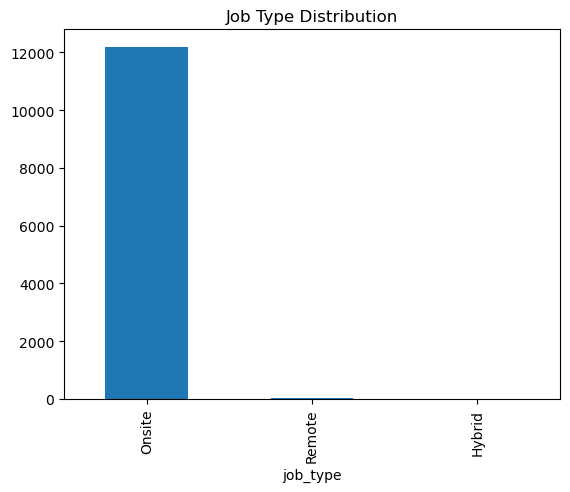

In [93]:
analysis_df["job_type"].value_counts().plot(
    kind="bar",
    title="Job Type Distribution"
)

### Job level

In [96]:
analysis_df["job_level"].value_counts()

job_level
Mid senior    10919
Associate      1298
Name: count, dtype: int64

In [98]:
pd.crosstab(
    analysis_df["job_level"],
    analysis_df["job_type"]
)

job_type,Hybrid,Onsite,Remote
job_level,,,
Associate,3,1288,7
Mid senior,8,10900,11


### Which positions have the most remote opportunities?

In [101]:
pd.crosstab(
    analysis_df["search_position"],
    analysis_df["job_type"],
    normalize="index"
)

job_type,Hybrid,Onsite,Remote
search_position,,,
Abstractor,0.025641,0.666667,0.307692
Account Executive,0.400000,0.360000,0.240000
Accountant,0.000000,1.000000,0.000000
Accountant Cost,0.000000,1.000000,0.000000
Accountant Property,0.000000,1.000000,0.000000
...,...,...,...
Utilization Engineer,0.000000,1.000000,0.000000
Value Engineer,0.000000,1.000000,0.000000
Vendor,0.000000,1.000000,0.000000


In [103]:
analysis_df["date"] = analysis_df["first_seen"].dt.date

In [105]:
analysis_df.groupby("date").size()

date
2024-01-12    1722
2024-01-13    4946
2024-01-14    3194
2024-01-15     871
2024-01-16    1211
2024-01-17     273
dtype: int64

In [107]:
analysis_df["month"] = analysis_df["first_seen"].dt.to_period("M")

In [109]:
monthly_jobs = analysis_df.groupby("month").size()

In [111]:
pd.crosstab(
    analysis_df["search_country"],
    analysis_df["job_type"]
)

job_type,Hybrid,Onsite,Remote
search_country,,,
Australia,1,300,0
Canada,0,630,0
United Kingdom,2,992,1
United States,8,10266,17
